# Qualitative reconstruction of SIR dynamics

We qualitatively assess the epidemiological plausibility of the SIR-INN by
comparing the reconstructed latent dynamics with the corresponding observed
quantities in the training set.

Specifically, we randomly select a subset of epidemic scenarios and visualize
the model outputs under different representations:

- the full SIR compartmental dynamics,
- the infectious compartment only,
- the inferred ILI incidence, computed from the susceptible trajectory.

This analysis is purely qualitative and aims to verify that the learned
dynamics are consistent with expected epidemiological behaviour, rather than
to provide a quantitative evaluation.

## 1. Setup and environment

We load the required libraries and project modules.
The repository root is added to the Python path to enable local imports.

In [6]:
import sys
from pathlib import Path

# Add repository root to Python path
repo_root = Path().resolve().parent
sys.path.append(str(repo_root))

# Standard
import torch
from torch import nn

# Project modules
# Neural Network loader 
from src.models.sir_inn import NN
# Evaluation utils
from src.evaluation.epidemiology import incidence_from_sir, plot_sir_inn_learning, sample_scenarios_by_R0
# Data loader
from src.data.data_loader import load_train_data

## 2. Load the pre-trained SIR-INN model and the data 

We firstly load the dataset used for the training and the PINN.

In [7]:
# This returns a torch tensor with the relevant features only
x_train, y_train, idx_train = load_train_data("../data/SIR-INN_dataset.csv")

# Convert tensors to numpy arrays for plotting
x_train_np = x_train.detach().numpy()
y_train_np = y_train.detach().numpy()

# Load pretrained SIR-INN model
# The model approximates the continuous-time SIR dynamics
activation = nn.Tanh
dimensions = [3, 16, 32, 16, 3]
sir_inn = NN(activation=activation, dimensions=dimensions)
sir_inn.load_state_dict(torch.load("../checkpoints/SIR-INN_pretrained.pth", map_location='cpu'))

sir_inn.eval()

NN(
  (stack): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=3, bias=True)
    (7): Sigmoid()
  )
)

## 3. Qualitative reconstruction of SIR dynamics

A subset of epidemic scenarios is randomly sampled from the training set to
provide representative qualitative examples.

The type of visualization is controlled via a configuration flag, allowing
inspection of different aspects of the learned dynamics.

In [8]:
# Reconstruct SIR dynamics from the pretrained SIR-INN
# The model outputs continuous-time approximations of S(t), I(t), R(t)

with torch.no_grad():
    sir_pred = sir_inn(x_train).detach().numpy()

S_pred = sir_pred[:, 0]
I_pred = sir_pred[:, 1]
R_pred = sir_pred[:, 2]

# Observed SIR components (used for qualitative comparison)
S_obs = y_train_np[:, 0]
I_obs = y_train_np[:, 1]
R_obs = y_train_np[:, 2]

In [9]:
# Selection of representative epidemic scenarios
idx_plot = sample_scenarios_by_R0(
    x_train_np, idx_train, n_samples=12
)

In [10]:
# Flag to choose between plotting all compartments, the infectious compartment, and the infectious incidence
plot_type = 'incidence'  # choose 'SIR', 'I', or 'incidence'

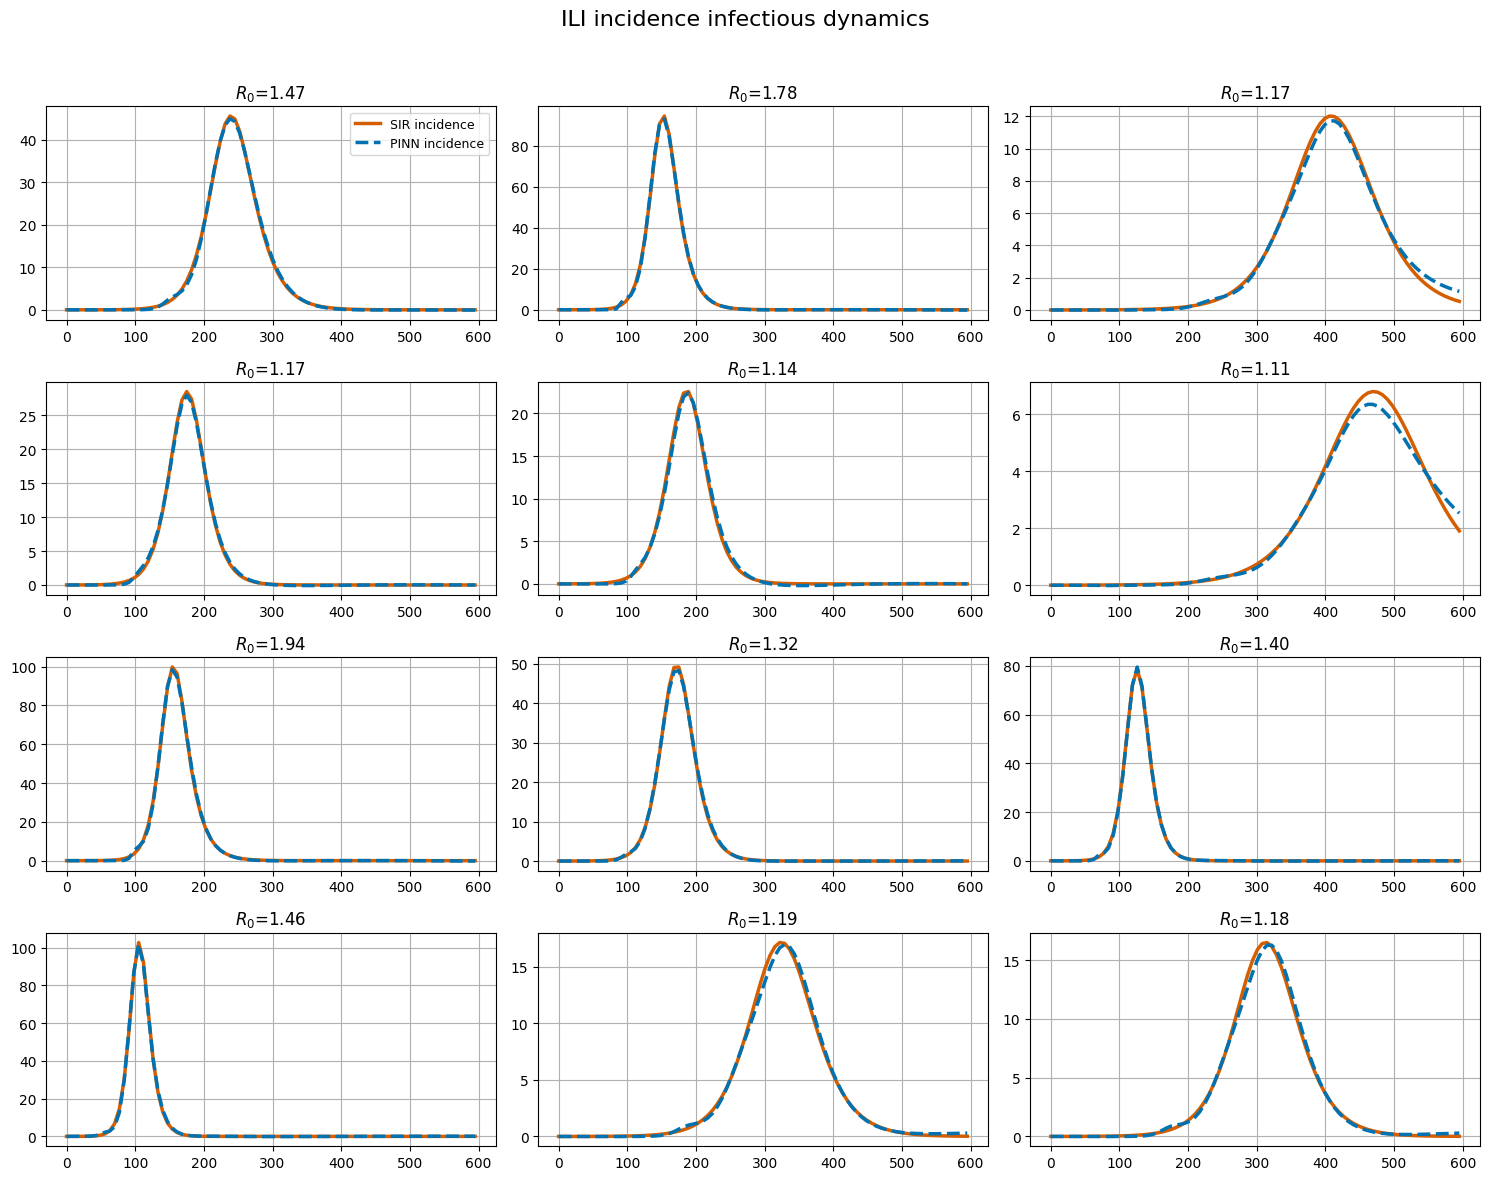

In [11]:
plot_sir_inn_learning(
    x_train_np=x_train_np,
    idx_train=idx_train,
    idx_plot=idx_plot,
    S_obs=S_obs,
    I_obs=I_obs,
    R_obs=R_obs,
    S_pred=S_pred,
    I_pred=I_pred,
    R_pred=R_pred,
    plot_type=plot_type
)

This qualitative analysis supports the use of the pretrained SIR-INN as an accurate surrogate of a disease spreading dynamics and a prior for the Bayesian inference and forecasting procedures presented in the following notebook (`02_forecast_mcmc.ipynb`).